<a href="https://colab.research.google.com/github/lucabarattini/COMS-W4721/blob/main/COMS_W4721_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# Assignment #3 - Luca Barattini - UNI: LB3656
## Problem I:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Simulate the data
np.random.seed(42)
mu = np.array([20, 0])
cov = np.array([[1, 0], [0, 9]])
X = np.random.multivariate_normal(mu, cov, 100)

# Function to perform PCA manually using SVD
def perform_pca(data, k=1):
    # Compute the covariance matrix
    cov_matrix = (data.T @ data) / data.shape[0]
    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    # Sort eigenvectors by decreasing eigenvalues
    sorted_idx = np.argsort(eigenvalues)[::-1]
    # U matrix (k x d) with orthonormal rows
    U = eigenvectors[:, sorted_idx][:, :k].T
    return U

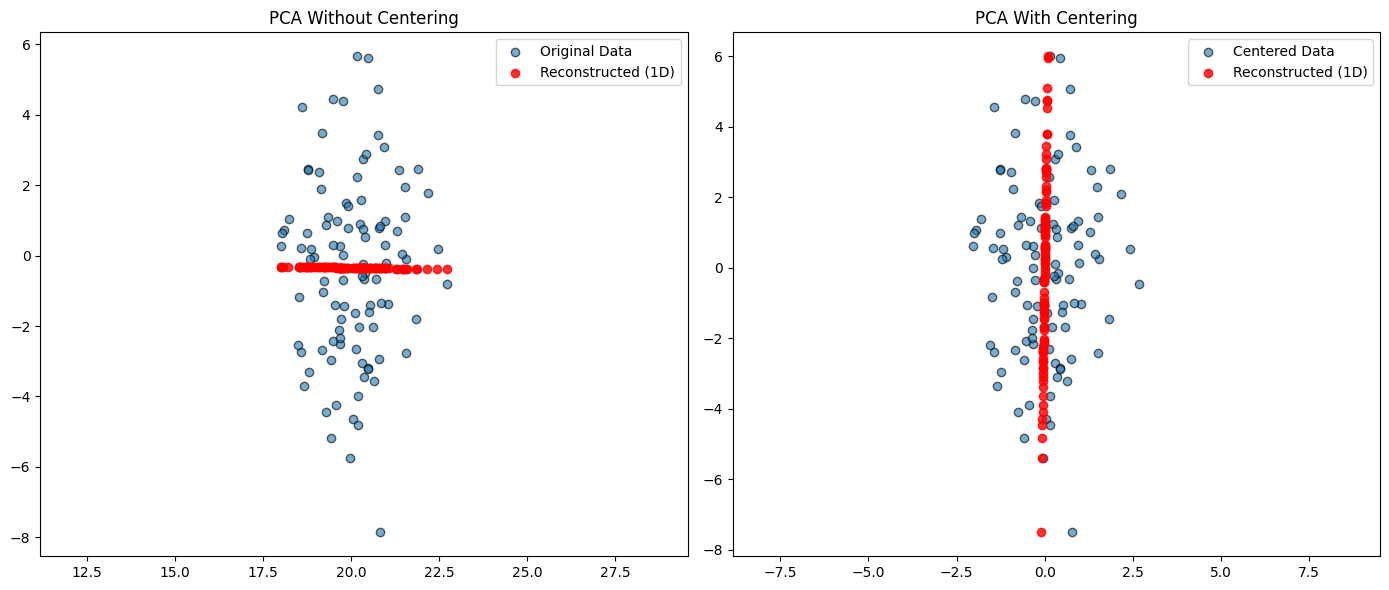

In [ ]:
# --- Without Centering ---
U_uncentered = perform_pca(X, k=1)
# Project to 1D and reconstruct to 2D (X_rec = X @ U^T @ U)
X_rec_uncentered = X @ U_uncentered.T @ U_uncentered

# --- With Centering ---
X_centered = X - np.mean(X, axis=0)
U_centered = perform_pca(X_centered, k=1)
# Project and reconstruct the centered data
X_rec_centered = X_centered @ U_centered.T @ U_centered

# 2. Produce the plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Plot 1: Uncentered
axes[0].scatter(X[:, 0], X[:, 1], label='Original Data', alpha=0.6, edgecolors='k')
axes[0].scatter(X_rec_uncentered[:, 0], X_rec_uncentered[:, 1], color='red', label='Reconstructed (1D)', alpha=0.8)
axes[0].set_title("PCA Without Centering")
axes[0].axis('equal') # Keeps the aspect ratio true to the variance
axes[0].legend()

# Plot 2: Centered
axes[1].scatter(X_centered[:, 0], X_centered[:, 1], label='Centered Data', alpha=0.6, edgecolors='k')
axes[1].scatter(X_rec_centered[:, 0], X_rec_centered[:, 1], color='red', label='Reconstructed (1D)', alpha=0.8)
axes[1].set_title("PCA With Centering")
axes[1].axis('equal')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Problem II:

In [ ]:
import numpy as np
from sklearn.datasets import load_digits

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

In [ ]:
# 1. Load and center the data
digits = load_digits()
X = digits.data
y_true = digits.target # True labels for later evaluation
X_centered = X - np.mean(X, axis=0)

# 2. Compute SVD / PCA to find singular values
pca = PCA().fit(X_centered)
singular_values = pca.singular_values_

# 3. Calculate Explained Variance ratio as defined mathematically
squared_singular_values = singular_values ** 2
explained_variance_ratio = np.cumsum(squared_singular_values) / np.sum(squared_singular_values)

# 4. Find the smallest k where explained variance >= 0.9
k = np.argmax(explained_variance_ratio >= 0.9) + 1 # +1 because indices are 0-based
print(f"The smallest value of k is: {k}")

The smallest value of k is: 21


In [ ]:
# Get the PCA-reduced data using the k we found
X_pca = PCA(n_components=k).fit_transform(X_centered)

# Initialize models (random_state fixed for reproducibility)
kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')
gmm = GaussianMixture(n_components=10, random_state=42)

# 1. k-means on Original Centered Data
kmeans_orig_labels = kmeans.fit_predict(X_centered)
ari_kmeans_orig = adjusted_rand_score(y_true, kmeans_orig_labels)

# 2. k-means on PCA-reduced Data
kmeans_pca_labels = kmeans.fit_predict(X_pca)
ari_kmeans_pca = adjusted_rand_score(y_true, kmeans_pca_labels)

# 3. GMM on Original Centered Data
gmm_orig_labels = gmm.fit_predict(X_centered)
ari_gmm_orig = adjusted_rand_score(y_true, gmm_orig_labels)

# 4. GMM on PCA-reduced Data
gmm_pca_labels = gmm.fit_predict(X_pca)
ari_gmm_pca = adjusted_rand_score(y_true, gmm_pca_labels)

print(f"K-Means ARI (Original): {ari_kmeans_orig:.4f}")
print(f"K-Means ARI (PCA-reduced): {ari_kmeans_pca:.4f}")
print(f"GMM ARI (Original): {ari_gmm_orig:.4f}")
print(f"GMM ARI (PCA-reduced): {ari_gmm_pca:.4f}")

K-Means ARI (Original): 0.7258
K-Means ARI (PCA-reduced): 0.6472
GMM ARI (Original): 0.7021
GMM ARI (PCA-reduced): 0.7389
